In [46]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.colors import ListedColormap
from IPython.display import HTML
from pathlib import Path

In [47]:
# J > 0: Ferromagnetic, J < 0: Antiferromagnetic
# Takes a configuration and the coefficient J and computes the energy.
def energy(conf, J, B):
    X, Y = conf.shape
    E = 0
    for x in range(X):
        for y in range(Y):
            E -= J*conf[x,y]*conf[(x+1)%X,y]
            E -= J*conf[x,y]*conf[x,(y+1)%Y]
            E += B*conf[x,y]
    return E

# Computes the variation in energy for a spin flip given the configuration
# and the coordinates of the flipping site.

def calc_dE(conf, x, y, J, B):
    X, Y = conf.shape
    dE = 0
    dE += conf[(x-1)%X,y]+conf[(x+1)%X,y]+conf[x,(y-1)%Y]+conf[x,(y+1)%Y]
    dE *= 2*J
    dE -= 2*B
    dE *= conf[x,y]
    
    return dE

def step_metropolis(conf, J, B, T, speed):
    N = conf.shape[0]
    for _ in range(int(speed*N*N)):
        # A site is chosen at random
        x = np.random.randint(0, N)
        y = np.random.randint(0, N)

        # Compute the change in energy if we flip that site
        dE = calc_dE(conf, x, y, J, B)
        # Transition probability
        p = np.exp(-dE/T)
        # If the energy decreases, the site flips
        if dE <= 0:
            conf[x,y] = -conf[x,y]
        # If the energy increases, the site flips with probability p.
        elif np.random.rand() <= p:
                conf[x,y] = -conf[x,y]
    return conf

def run_metropolis(N, J, B, T, it):
    conf = np.random.choice([-1, 1], (N,N))
    E = energy(conf, J, B)
    Es = [E]
    for _ in range(it):
        # A site is chosen at random
        x = np.random.randint(0, N)
        y = np.random.randint(0, N)

        # Compute the change in energy if we flip that site
        dE = calc_dE(conf, x, y, J, B)
        # Transition probability
        p = np.exp(-dE/T)
        # If the energy decreases, the site flips
        if dE <= 0:
            conf[x,y] = -conf[x,y]
            E += dE
        # If the energy increases, the site flips with probability p.
        elif np.random.rand() <= p:
                conf[x,y] = -conf[x,y]
                E += dE
        Es.append(E)
    #plt.imshow(conf)
    #plt.show()
    return Es

The algorithm runs in O(N)! (N being the number of iterations). A bigger system doesn't take longer, as numpy array access is O(1) and each iteration only accesses the array and computes the energy difference, which takes 4 calculations.

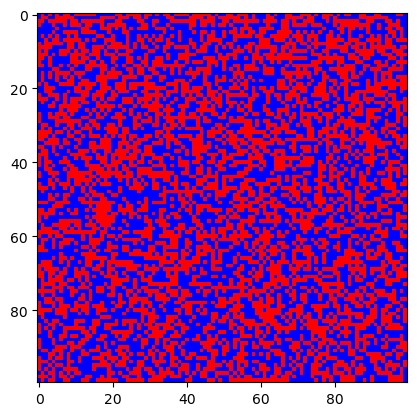

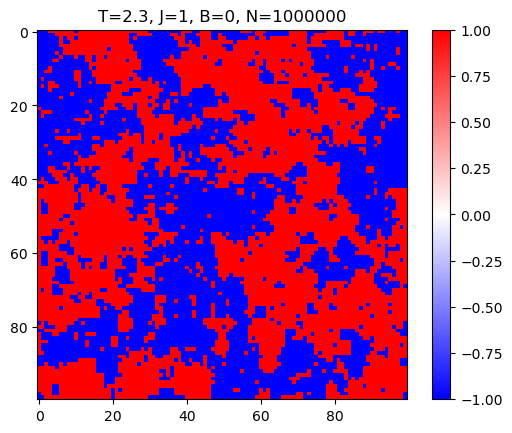

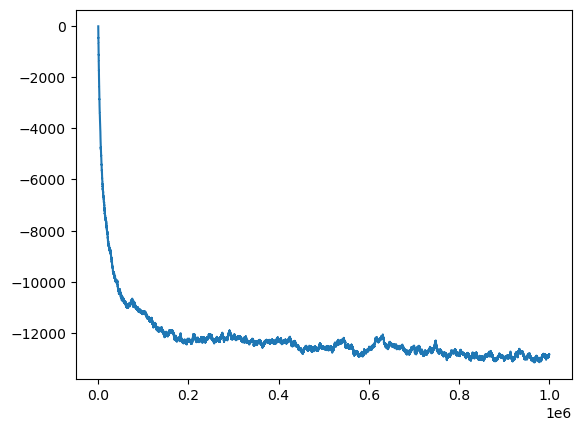

In [48]:
# J > 0: Ferromagnetic, J < 0: Antiferromagnetic
X = 100
Y = 100
J = 1
B = 0

T = 2.3 # temperature

# Initial state
conf = np.random.choice([1,-1], (X,Y))
conf[20,20]=-1

# Initial energy
E = energy(conf, J, B)
Es = [E] # we track the evolution of the energy

# Plot initial state
#plt.figure(figsize=(10, 10))
plt.imshow(conf, cmap='bwr', interpolation='none')
plt.show()

# We apply the metropolis algorithm N times
N = 1000000
for i in range(N):
    # A site is chosen at random
    x = np.random.randint(0, X)
    y = np.random.randint(0, Y)

    # Compute the change in energy if we flip that site
    dE = calc_dE(conf, x, y, J, B)
    # Transition probability
    p = np.exp(-dE/T)
    # If the energy decreases, the site flips
    if dE <= 0:
        conf[x,y] = -conf[x,y]
        E += dE
    # If the energy increases, the site flips with probability p.
    elif np.random.rand() <= p:
            conf[x,y] = -conf[x,y]
            E += dE
    '''
    # This version flips always with probability p.
    if np.random.rand() <= p:
        conf[x,y] = -conf[x,y]
        E += dE
    '''
    Es.append(E)
        
#plt.figure(figsize=(10, 10))
plt.title(f"T={T}, J={J}, B={B}, N={N}")
img = plt.imshow(conf, cmap='bwr', interpolation='none')
plt.colorbar(img)
plt.clim(-1, 1)

plt.show()
#plt.savefig("../figures/")
plt.plot(Es)

plt.show()

In [ ]:
#Ts = np.linspace(0.01, 40, 100)
Ts = np.logspace(-2, 5, 100, base=10)
Cts = []
J0 = 2
B0 = 0
N = 150
it = 50000

#run_metropolis(N, J0, B0, 1, it)

for T in Ts:
     conf = np.random.choice([-1,1], (N,N))
     Es = np.array(run_metropolis(N, J0, B0, T, it))
     Cts.append(np.var(Es)/T**2)

/tmp/ipykernel_4417/3146294165.py:57: RuntimeWarning: overflow encountered in exp
  p = np.exp(-dE/T)


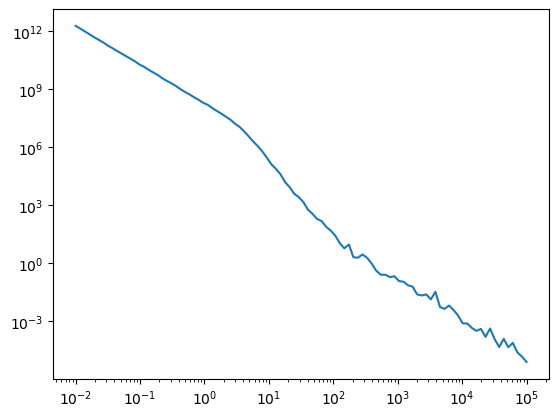

In [59]:
plt.yscale('log')
plt.xscale('log')
plt.plot(Ts, Cts)

In [51]:
def load_states(filename):
  with h5py.File(filename, 'r') as f:
    states = f['configurations'][:]

    # Read metadata
    metadata = {
        'J': f['metadata'].attrs['J'],
        'T': f['metadata'].attrs['T'],
        'N': f['metadata'].attrs['N'],
        'X': f['metadata'].attrs['X'],
        'Y': f['metadata'].attrs['Y'],
        'step_size': f['metadata'].attrs['step_size'],
        'dimensions': (f['metadata'].attrs['X'], f['metadata'].attrs['Y'])
    }
  return states, metadata

def jupyter_animation(configurations, step_size, filename='ising_animation.gif', cmap='cool', fps=20):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Configuration initiale
    im = ax.imshow(configurations[0], cmap=cmap, vmin=-1, vmax=1)
    ax.axis('off')  # Enlever les axes pour plus de clarté
    title = ax.set_title("Frame 0", fontsize=14)
    
    # Fonction de mise à jour
    def update(frame):
        im.set_array(configurations[frame])
        title.set_text(f"Configuration {frame * step_size}")
        return [im, title]
    
    # Créer l'animation
    anim = FuncAnimation(fig, update, frames=len(configurations),
                        interval=1000/fps, blit=True)
    
    plt.tight_layout()

    save_path = Path('..').resolve() / 'animations' / filename
    anim.save(save_path, writer='pillow', fps=fps) 
    print(f"Animation saved to {save_path}")
    
    # Afficher dans le notebook
    plt.close()
    return HTML(anim.to_jshtml())

In [52]:
configs, metadata = load_states('../data/antifer-config-froid.h5')
jupyter_animation(configs, metadata['step_size'], 'antifer-config-froid.gif')

FileNotFoundError: [Errno 2] Unable to open file (unable to open file: name = '../data/antifer-config-froid.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)